Distribusi Kelas SEBELUM Balancing:
label
Overstride     9242
Normal         1526
Heel_Strike     722
Name: count, dtype: int64
--------------------------------------------------

Distribusi Kelas SESUDAH Balancing:
label
Overstride     722
Heel_Strike    722
Normal         722
Name: count, dtype: int64
--------------------------------------------------

Shape Input untuk CNN: (1732, 133, 1)
Total Data Training: 1732
Total Data Validation: 434
--------------------------------------------------
Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_21 (Conv1D)          (None, 133, 32)           128       
                                                                 
 batch_normalization_21 (Bat  (None, 133, 32)          128       
 chNormalization)                                                
                                                                 
 max_pooling1d_18

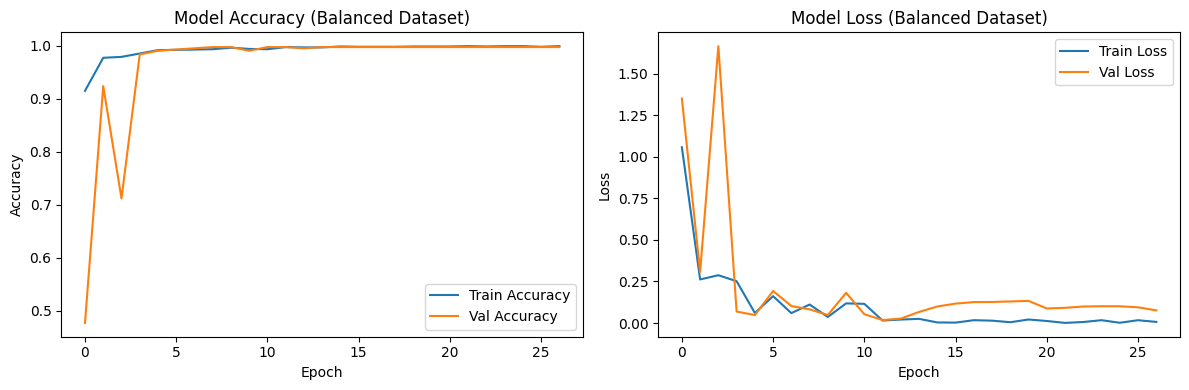


✅ EKSEKUSI SELESAI!
Model (.h5), Scaler (.pkl), dan Encoder (.pkl) berhasil disimpan di folder: ../models/


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models
import joblib
import os

# =========================================================
# 1. KONFIGURASI PATH
# =========================================================
DATA_PATH = '../data/results/running_dataset.csv'
MODEL_DIR = '../models/'

if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

# =========================================================
# 2. LOAD DATA & BALANCING (UNDERSAMPLING)
# =========================================================
df = pd.read_csv(DATA_PATH)

print("Distribusi Kelas SEBELUM Balancing:")
print(df['label'].value_counts())
print("-" * 50)

# Menentukan batas maksimal sampling sesuai permintaan (722)
MAX_SAMPLES = 722

# Memisahkan data per kelas
df_normal = df[df['label'] == 'Normal']
df_heel = df[df['label'] == 'Heel_Strike']
df_overstride = df[df['label'] == 'Overstride']

# Melakukan undersampling dengan batasan MAX_SAMPLES
# Menggunakan fungsi min() agar aman jika data aslinya kurang dari 722
df_normal_sampled = df_normal.sample(n=min(MAX_SAMPLES, len(df_normal)), random_state=42)
df_heel_sampled = df_heel.sample(n=min(MAX_SAMPLES, len(df_heel)), random_state=42)
df_overstride_sampled = df_overstride.sample(n=min(MAX_SAMPLES, len(df_overstride)), random_state=42)

# Menggabungkan kembali dataframe yang sudah seimbang
df_balanced = pd.concat([df_normal_sampled, df_heel_sampled, df_overstride_sampled])

# Mengacak urutan baris agar model tidak belajar secara berurutan
df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDistribusi Kelas SESUDAH Balancing:")
print(df['label'].value_counts())
print("-" * 50)

# =========================================================
# 3. PRA-PEMROSESAN & SPLITTING
# =========================================================
# Memisahkan Fitur (X) dan Label (y)
# Drop 'label' dan 'source_video' karena tidak dipakai sebagai input neural network
X = df.drop(['label', 'source_video'], axis=1, errors='ignore').values
y = df['label'].values

# Encode Label (Ubah teks menjadi angka: 0, 1, 2)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Standarisasi Fitur (Wajib untuk Neural Network agar konvergen)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# =========================================================
# 4. RESHAPE UNTUK CNN 1D
# =========================================================
# Layer Conv1D butuh input 3 dimensi: (jumlah_sampel, fitur, channel)
X_train_cnn = np.expand_dims(X_train, axis=2)
X_test_cnn = np.expand_dims(X_test, axis=2)

print(f"\nShape Input untuk CNN: {X_train_cnn.shape}")
print(f"Total Data Training: {len(X_train_cnn)}")
print(f"Total Data Validation: {len(X_test_cnn)}")
print("-" * 50)

# =========================================================
# 5. ARSITEKTUR MODEL CNN 1D
# =========================================================
model = models.Sequential([
    # Layer Input
    layers.Input(shape=(X_train_cnn.shape[1], 1)),

    # Block Konvolusi 1
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    # Block Konvolusi 2
    layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    # Block Konvolusi 3
    layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    
    # Ratakan matriks ke vektor 1D
    layers.Flatten(),

    # Fully Connected Layer (Klasifikasi Akhir)
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Regularisasi untuk mencegah overfitting
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    
    # Layer Output (Jumlah neuron = Jumlah kelas)
    layers.Dense(len(encoder.classes_), activation='softmax')
])

# Kompilasi Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Tampilkan ringkasan arsitektur
model.summary()

# =========================================================
# 6. TRAINING MODEL (DENGAN CALLBACKS)
# =========================================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("\nMemulai Proses Training...")

# 1. Setup Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15,                # Toleransi 15 epoch jika val_loss tidak membaik
    restore_best_weights=True,  # SANGAT PENTING: Kembalikan model ke performa terbaiknya
    verbose=1
)

# 2. Setup Reduce Learning Rate on Plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,                 # Potong learning rate menjadi 50%
    patience=5,                 # Jika dalam 5 epoch berturut-turut val_loss stagnan/naik
    min_lr=1e-6,                # Batas bawah learning rate
    verbose=1
)

# 3. Eksekusi Training dengan penambahan param 'callbacks'
history = model.fit(X_train_cnn, y_train,
                    epochs=150,
                    batch_size=32,
                    validation_data=(X_test_cnn, y_test),
                    callbacks=[early_stop, reduce_lr] # <--- Injeksi Callbacks di sini
)

# =========================================================
# 7. EVALUASI & VISUALISASI
# =========================================================
from sklearn.metrics import classification_report

print("\n--- Hasil Evaluasi pada Data Testing ---")
y_pred = np.argmax(model.predict(X_test_cnn), axis=1)
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# Plotting Grafik Akurasi & Loss
plt.figure(figsize=(12, 4))

# Subplot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (Balanced Dataset)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Subplot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (Balanced Dataset)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 8. SIMPAN MODEL & SUPPORT FILES
# =========================================================
model.save(os.path.join(MODEL_DIR, 'runform_model.h5'))
joblib.dump(scaler, os.path.join(MODEL_DIR, 'scaler.pkl'))
joblib.dump(encoder, os.path.join(MODEL_DIR, 'label_encoder.pkl'))

print(f"\n✅ EKSEKUSI SELESAI!")
print(f"Model (.h5), Scaler (.pkl), dan Encoder (.pkl) berhasil disimpan di folder: {MODEL_DIR}")